In [1]:
import hydra
import os
from hydra import initialize, initialize_config_module, initialize_config_dir, compose
from omegaconf import OmegaConf
from wandb_helper.manager import RunsManager
from wandb_helper.processors import chain
import pprint

In [2]:
def identity(df):
    return df

def handle_nans(df):
    # replace nans in "confidence" with "null"
    df["confidence"] = df["confidence"].fillna("null")
    df["top_k"] = df["top_k"].fillna(0)
    df["top_p"] = df["top_p"].fillna(0)

    return df

processor = chain(
    handle_nans,
)


In [3]:
with initialize(config_path="wandb_helper/configs", version_base=None):
    config = compose(config_name="config", overrides=["run_filter=owt_bptt_200k", "name=owt_bptt_200k", "wandb_entity=ilm-extensions", "wandb_project=BPTT"])
manager = hydra.utils.instantiate(_target_="wandb_helper.manager.RunsManager", _convert_="partial",config=config, value_processor=processor)
figures_dir = "plots"

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/dhruveshpate_umass_edu/.netrc.


In [5]:
df = manager.df(force_refresh_from_wandb=True, force_refresh_from_local=True)

Attempting to load runs from local raw runs
Getting runs from ilm-extensions/BPTT


In [6]:
print(df.columns)
df

Index(['run_id', 'top_k', 'Gen. NLL', 'tags.dataset', 'sampling_steps', 'loss',
       'Gen. Perplexity', 'tags.checkpoint', 'Gen. Length', 'Gen. Entropy',
       'tags.model', 'seed', 'tags.job_type', 'tags.correlated_t', 'tags.T',
       'top_p', 'Model', 'tags.debug', 'threshold', 'confidence',
       'tags.noise_schedule'],
      dtype='str')


,run_id,top_k,Gen. NLL,tags.dataset,sampling_steps,loss,Gen. Perplexity,tags.checkpoint,Gen. Length,Gen. Entropy,...,seed,tags.job_type,tags.correlated_t,tags.T,top_p,Model,tags.debug,threshold,confidence,tags.noise_schedule
0,so068bo5,0,4.849071,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,127.760147,0-200000,1017.305444,5.187581,...,1,eval,False,0,1.0,loopholing_bptt_puma,False,0.100,top_prob,dummy
1,mznqr26e,0,4.834554,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,125.771248,0-200000,1018.244960,5.163559,...,1,eval,False,0,1.0,loopholing_bptt_puma,False,0.010,top_prob,dummy
2,kipkbpgi,0,4.832847,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,125.569313,0-200000,1018.069556,5.164480,...,1,eval,False,0,1.0,loopholing_bptt_puma,False,0.001,top_prob,dummy
3,njzm6cx1,0,4.838257,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,126.303780,0-200000,1017.894153,5.162041,...,1,eval,False,0,1.0,loopholing_bptt_puma,False,0.150,top_prob,dummy
4,2lp29a74,0,4.038851,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,56.812206,0-200000,1018.875000,4.858611,...,1,eval,False,0,0.9,loopholing_bptt_puma,False,0.001,top_prob,dummy
5,8kf21n64,0,4.850662,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,127.873970,0-200000,1016.809476,5.170545,...,1,eval,False,0,1.0,loopholing_bptt_puma,False,0.200,top_prob,dummy
6,ob2gt25t,0,4.064232,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,58.212452,0-200000,1019.713710,4.884480,...,1,eval,False,0,0.9,loopholing_bptt_puma,False,0.010,top_prob,dummy
7,nfvxzhqj,0,4.062206,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,58.273243,0-200000,1016.744960,4.868047,...,1,eval,False,0,0.9,loopholing_bptt_puma,False,0.100,top_prob,dummy
8,3ngx9m5i,0,4.055458,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,57.709034,0-200000,1017.784274,4.863745,...,1,eval,False,0,0.9,loopholing_bptt_puma,False,0.150,top_prob,dummy
9,7svdegxz,0,4.047161,owt_packed,1024,doublebackprop.loss.LoopholingBPTTPumaLoss,57.283398,0-200000,1017.242944,4.853604,...,1,eval,False,0,0.9,loopholing_bptt_puma,False,0.200,top_prob,dummy


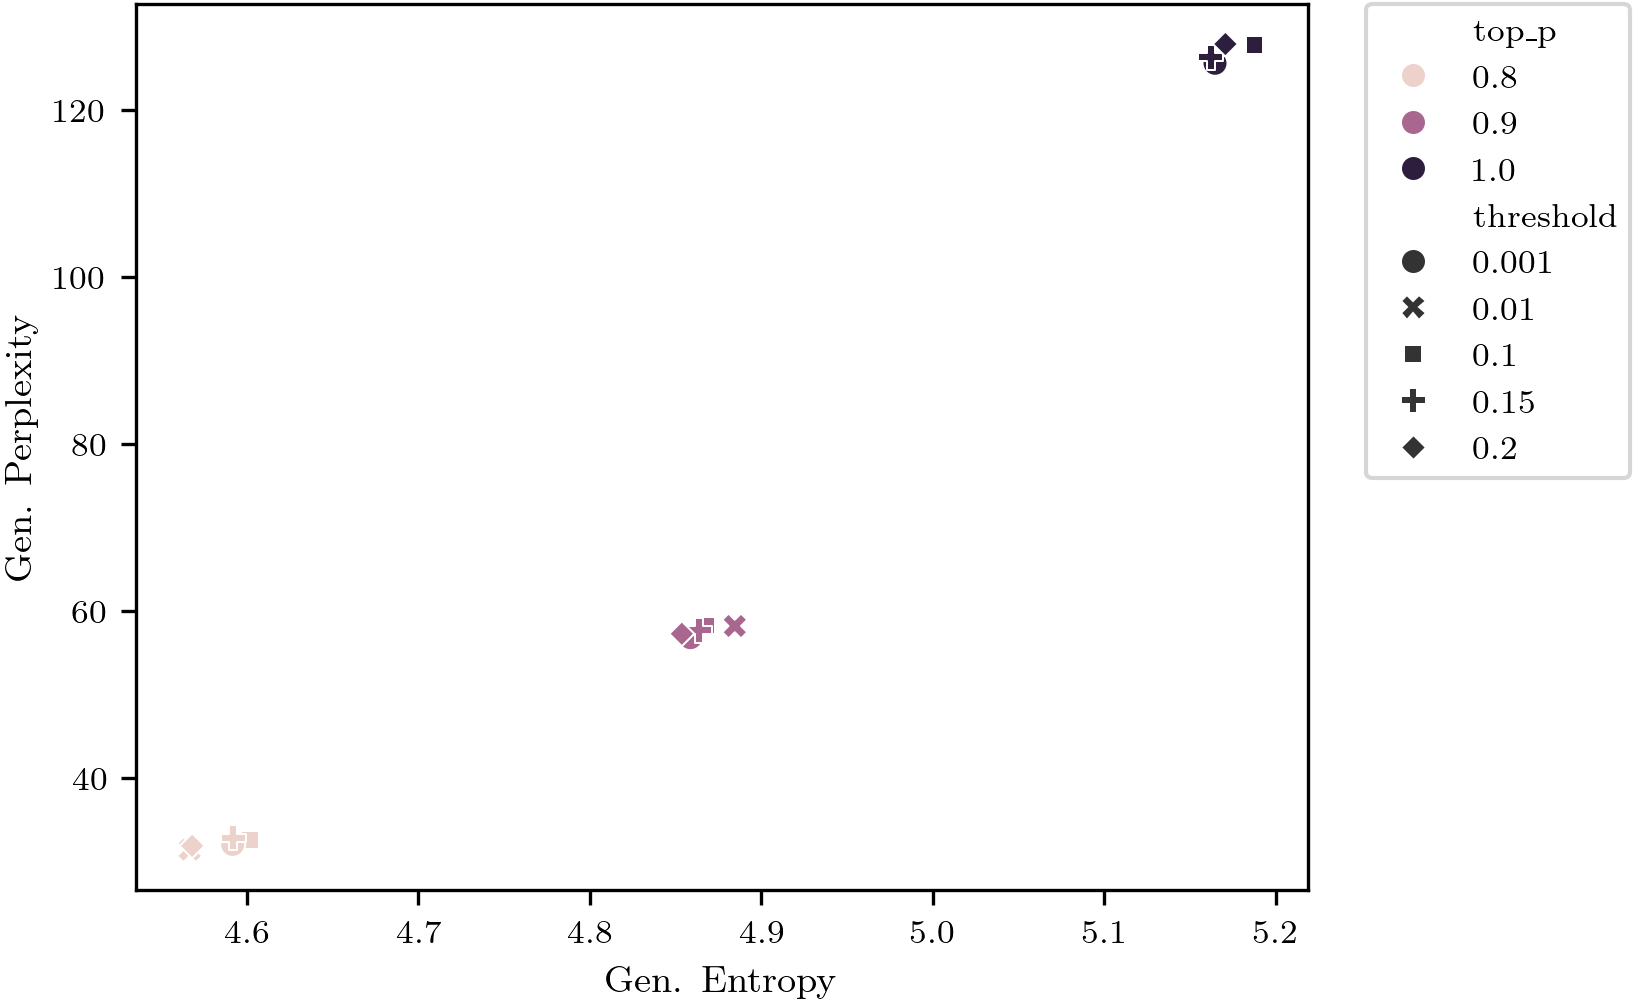

In [8]:
import pandas as pd
from mpl_colors import use_cics_style
from default_rcparams import neurips_rcparams
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
use_cics_style(n_cycle=6) 
rcparams = neurips_rcparams(font_family="serif", colsize="full")
#df_ = df[df["confidence"] == "null"]
df_ = df

with plt.rc_context(rcparams):
    sns.scatterplot(
        x="Gen. Entropy",
        y="Gen. Perplexity",
        hue="top_p",
        style="threshold",
        #style="correction_frequency",
        #markers=True,
        #dashes=False,
        data=df_,
        #ax=ax,
        #marker="o"
    )
    # move the legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()